# Torque-tracking integral loop vs baseline (RR_calf demag)

**비교 목적**: 같은 A+(coupled) 정책 + 같은 PPO 체크포인트로, 드라이버 안의 토크 추종 적분 루프를 켰을 때(`aplus_tloop`)와 끄고 PD-only 였던 기존 실험(`aplus`) 의 q 추종 / 전류 신호 차이를 본다.

**실험 조건 (양쪽 동일)**:
- task: `Unitree-Go2-Flat-Coupled[-Tloop]-Electric` (cfg 차이는 `use_torque_loop` 만)
- 체크포인트: `logs/rsl_rl/aplus_dynprm4/2026-04-28_13-27-02_seed42/model_1999.pt`
- 명령: vx=0.5 m/s, vy=0, wz=0
- 감자: RR_calf 단일 모터, factor ∈ {1.0, 0.8, 0.6, 0.4}
- 1000 step (= 20 s) 로깅

**가설**: 적분 루프가 켜지면 감자가 깊어져도 q_des−q 오차는 baseline 수준에 머무르고, 대신 I_cmd / I_actual 이 크게 상승해야 한다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_ROOT = Path('./data')
FACTORS = [1.0, 0.8, 0.6, 0.4]
JOINT = 'RR_calf_joint'

def case_path(policy: str, factor: float) -> Path:
    if factor >= 1.0:
        return DATA_ROOT / policy / 'healthy.npz'
    return DATA_ROOT / policy / f'RR_{factor:.1f}.npz'

def load_case(policy: str, factor: float):
    p = case_path(policy, factor)
    if not p.exists():
        raise FileNotFoundError(p)
    d = np.load(p, allow_pickle=True)
    meta = json.loads(str(d['meta']))
    return d, meta

def col_idx(meta, joint_name):
    return meta['q_all_joint_names'].index(joint_name)

for f in FACTORS:
    for p in ('aplus', 'aplus_tloop'):
        try:
            _ = case_path(p, f).resolve(strict=True)
            print(f'OK  {p:<12s} factor={f}')
        except FileNotFoundError:
            print(f'MISSING  {p:<12s} factor={f}')

OK  aplus        factor=1.0
OK  aplus_tloop  factor=1.0
OK  aplus        factor=0.8
OK  aplus_tloop  factor=0.8
OK  aplus        factor=0.6
OK  aplus_tloop  factor=0.6
OK  aplus        factor=0.4
OK  aplus_tloop  factor=0.4


## 1. 정상상태 q 추종 오차 요약 — RR_calf

두 정책 × 4 demag 케이스 = 8 셀. 각 셀에서 RR_calf 의 (q_des - q_actual) 의 RMS / mean / max-abs 를 마지막 10초 (500 step) 윈도우로 잡아 표로 정리.

- 적분 루프 OFF: factor 가 작아질수록 정상상태 droop 이 커져야 함 (≈ 1/α 배).
- 적분 루프 ON: factor 와 관계없이 healthy 수준 유지 가설.

In [2]:
import pandas as pd

def err_stats(d, meta, joint_name, tail_n=500):
    j = col_idx(meta, joint_name)
    q_des = d['q_des'][:, j]
    q     = d['q_all'][:, j]
    err   = q_des - q
    tail  = err[-tail_n:]
    return {
        'rms_err':  float(np.sqrt(np.mean(tail**2))),
        'mean_err': float(np.mean(tail)),
        'max_abs':  float(np.max(np.abs(tail))),
    }

rows = []
for f in FACTORS:
    for p in ('aplus', 'aplus_tloop'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        s = err_stats(d, m, JOINT)
        s.update({'policy': p, 'factor': f})
        rows.append(s)
df = pd.DataFrame(rows).set_index(['factor', 'policy'])[['rms_err', 'mean_err', 'max_abs']]
df.style.format('{:.4f}')

## 2. q_des / q_actual / 추종 오차 시계열 — 4 factor × 2 policy 그리드

윗줄: q_des(점선) vs q_actual(실선). 아랫줄: q_des - q_actual.
왼쪽부터 factor = 1.0 / 0.8 / 0.6 / 0.4. 두 정책 색으로 구분.

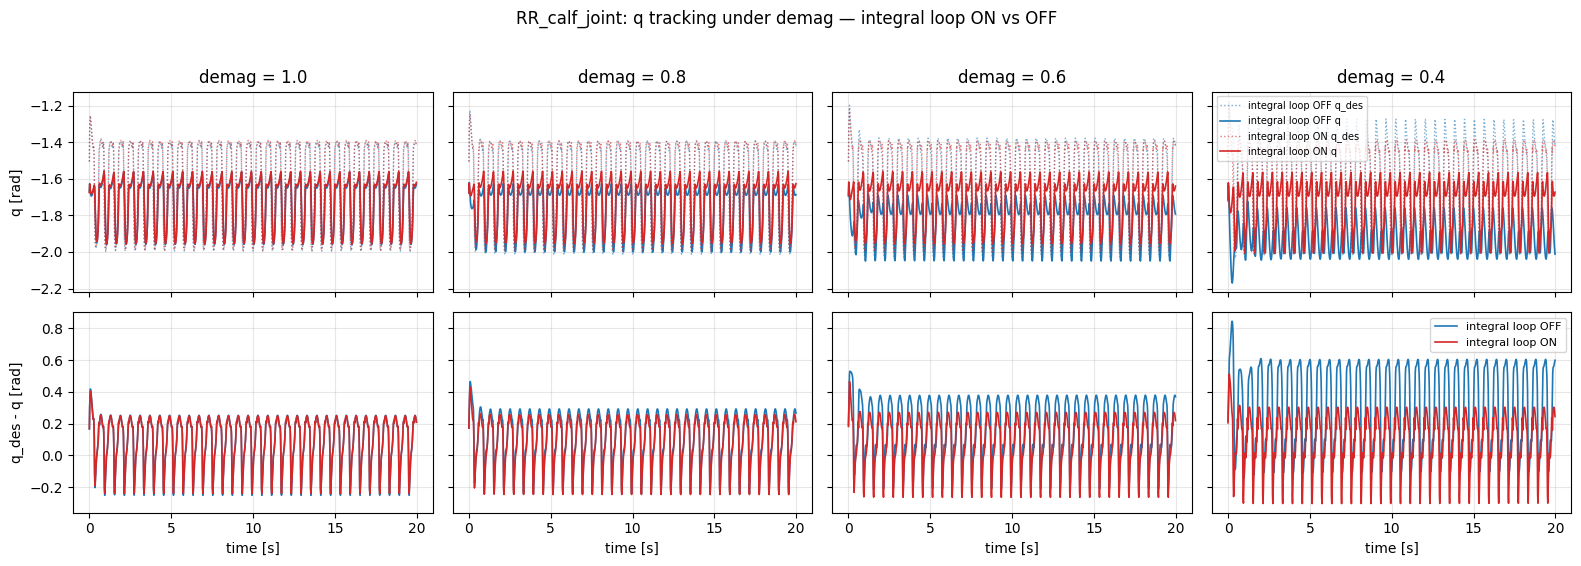

In [3]:
color = {'aplus': 'tab:blue', 'aplus_tloop': 'tab:red'}
label = {'aplus': 'integral loop OFF', 'aplus_tloop': 'integral loop ON'}

fig, axes = plt.subplots(2, len(FACTORS), figsize=(4*len(FACTORS), 5.5),
                         sharex=True, sharey='row')
for ci, f in enumerate(FACTORS):
    ax_top = axes[0, ci]
    ax_bot = axes[1, ci]
    for p in ('aplus', 'aplus_tloop'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        j = col_idx(m, JOINT)
        t = np.arange(m['num_steps']) * m['dt']
        q_des = d['q_des'][:, j]
        q     = d['q_all'][:, j]
        ax_top.plot(t, q_des, color=color[p], ls=':', lw=1.0, alpha=0.6,
                    label=f'{label[p]} q_des')
        ax_top.plot(t, q,     color=color[p], ls='-', lw=1.2,
                    label=f'{label[p]} q')
        ax_bot.plot(t, q_des - q, color=color[p], lw=1.2, label=label[p])
    ax_top.set_title(f'demag = {f}')
    ax_top.grid(alpha=0.3)
    ax_bot.grid(alpha=0.3)
    if ci == 0:
        ax_top.set_ylabel('q [rad]')
        ax_bot.set_ylabel('q_des - q [rad]')
    ax_bot.set_xlabel('time [s]')
axes[0, -1].legend(fontsize=7, loc='best')
axes[1, -1].legend(fontsize=8, loc='best')
fig.suptitle(f'{JOINT}: q tracking under demag — integral loop ON vs OFF', y=1.02)
fig.tight_layout()

## 3. 토크 / 전류 신호 — 진단 feature 검증

OFF 케이스에서는 τ_actual = α·τ_cmd 로 갈라지지만, ON 케이스에서는 τ_actual ≈ τ_cmd 가 유지되고 대신 I_cmd / I_actual 이 ≈ 1/α 배로 부풀어야 함.

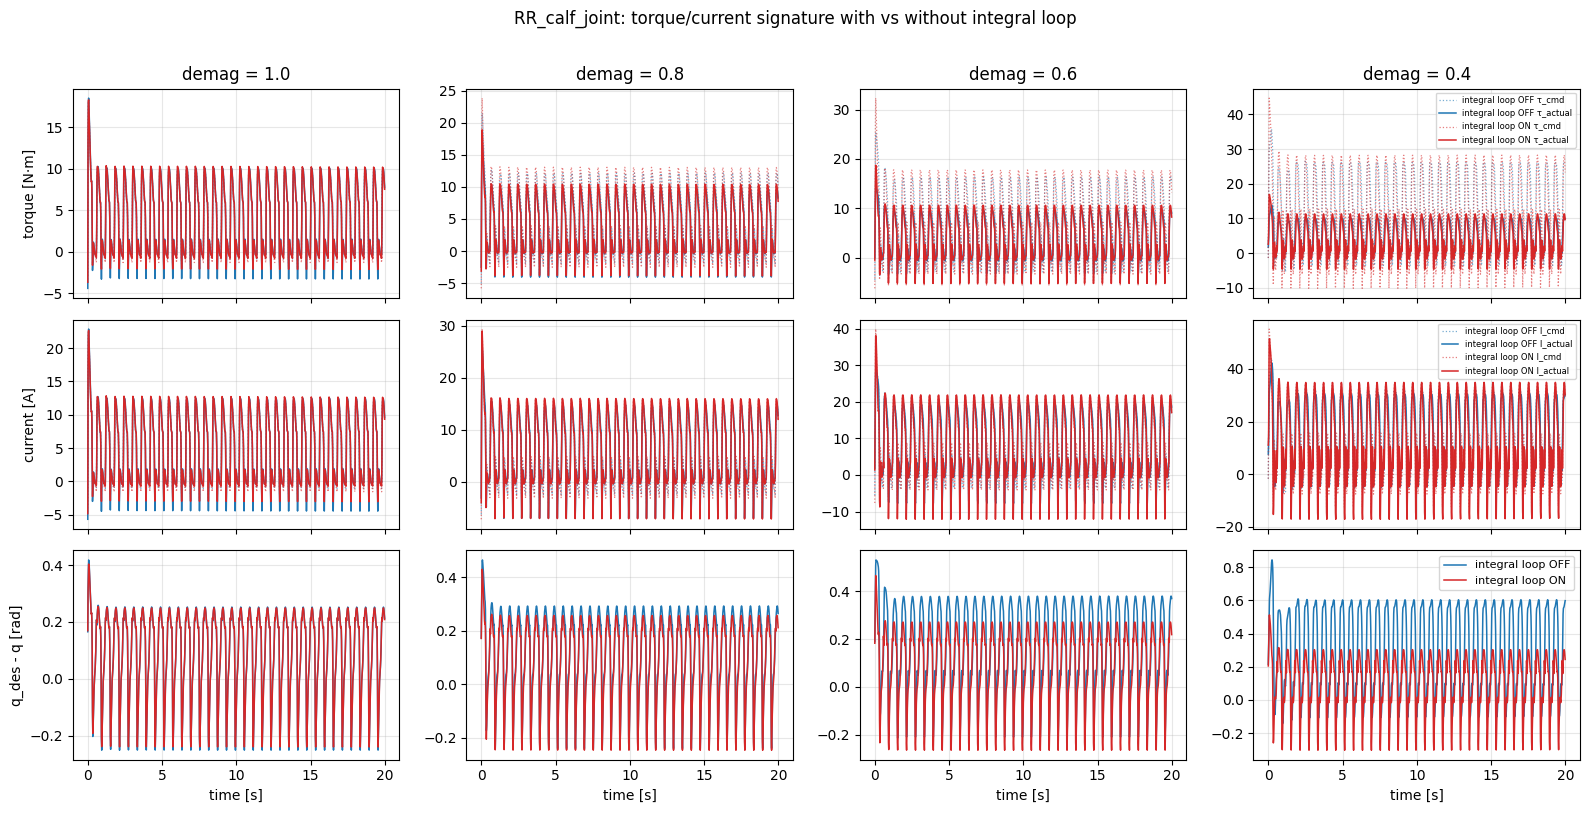

In [4]:
fig, axes = plt.subplots(3, len(FACTORS), figsize=(4*len(FACTORS), 8.0),
                         sharex=True)
for ci, f in enumerate(FACTORS):
    ax_tau = axes[0, ci]
    ax_I   = axes[1, ci]
    ax_qe  = axes[2, ci]
    for p in ('aplus', 'aplus_tloop'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        j = col_idx(m, JOINT)
        t = np.arange(m['num_steps']) * m['dt']
        ax_tau.plot(t, d['tau_cmd'][:, j],    color=color[p], ls=':',  lw=0.9, alpha=0.6,
                    label=f'{label[p]} τ_cmd')
        ax_tau.plot(t, d['tau_actual'][:, j], color=color[p], ls='-',  lw=1.1,
                    label=f'{label[p]} τ_actual')
        ax_I.plot(t, d['I_cmd'][:, j],    color=color[p], ls=':',  lw=0.9, alpha=0.6,
                  label=f'{label[p]} I_cmd')
        ax_I.plot(t, d['I_actual'][:, j], color=color[p], ls='-',  lw=1.1,
                  label=f'{label[p]} I_actual')
        ax_qe.plot(t, d['q_des'][:, j] - d['q_all'][:, j], color=color[p], lw=1.1,
                   label=label[p])
    ax_tau.set_title(f'demag = {f}')
    for ax in (ax_tau, ax_I, ax_qe):
        ax.grid(alpha=0.3)
    if ci == 0:
        ax_tau.set_ylabel('torque [N·m]')
        ax_I.set_ylabel('current [A]')
        ax_qe.set_ylabel('q_des - q [rad]')
    ax_qe.set_xlabel('time [s]')
axes[0, -1].legend(fontsize=6, loc='best')
axes[1, -1].legend(fontsize=6, loc='best')
axes[2, -1].legend(fontsize=8, loc='best')
fig.suptitle(f'{JOINT}: torque/current signature with vs without integral loop', y=1.01)
fig.tight_layout()

## 4. 정상상태 |I_actual| 비교 — 진단 신호 강도

감자 비율 vs 정상상태 |I_actual| (RR_calf, 마지막 10초 평균). ON 정책에서 1/α 배 가까운 비례성이 나오면 적분기가 정상 동작.

In [5]:
rows = []
for f in FACTORS:
    for p in ('aplus', 'aplus_tloop'):
        try:
            d, m = load_case(p, f)
        except FileNotFoundError:
            continue
        j = col_idx(m, JOINT)
        I_abs_ss = float(np.mean(np.abs(d['I_actual'][-500:, j])))
        tau_abs_ss = float(np.mean(np.abs(d['tau_actual'][-500:, j])))
        tcmd_abs_ss = float(np.mean(np.abs(d['tau_cmd'][-500:, j])))
        rows.append({'factor': f, 'policy': p,
                     '|I|_ss': I_abs_ss,
                     '|τ_actual|_ss': tau_abs_ss,
                     '|τ_cmd|_ss': tcmd_abs_ss,
                     'τ_actual/τ_cmd': tau_abs_ss / max(tcmd_abs_ss, 1e-6)})
ss = pd.DataFrame(rows).set_index(['factor', 'policy'])
ss.style.format('{:.4f}')

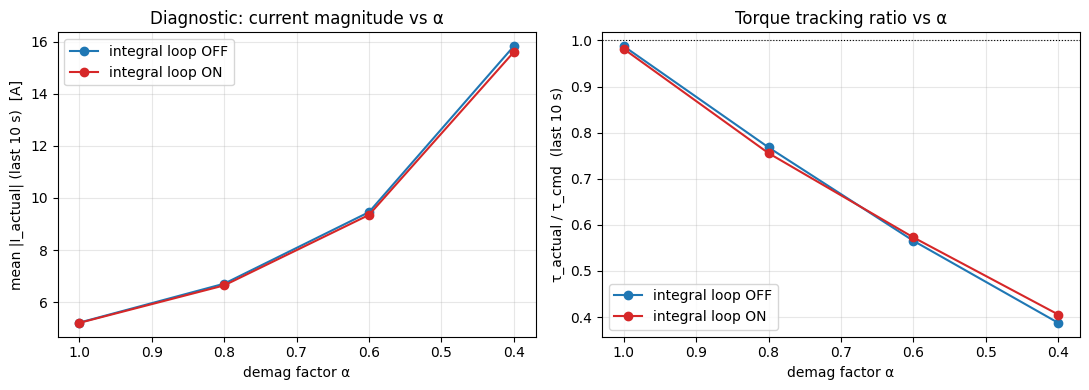

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for p in ('aplus', 'aplus_tloop'):
    sub = ss.xs(p, level='policy')
    ax[0].plot(sub.index, sub['|I|_ss'], 'o-', color=color[p], label=label[p])
    ax[1].plot(sub.index, sub['τ_actual/τ_cmd'], 'o-', color=color[p], label=label[p])
ax[0].set_xlabel('demag factor α')
ax[0].set_ylabel('mean |I_actual| (last 10 s)  [A]')
ax[0].set_title('Diagnostic: current magnitude vs α')
ax[0].invert_xaxis()
ax[1].set_xlabel('demag factor α')
ax[1].set_ylabel('τ_actual / τ_cmd  (last 10 s)')
ax[1].set_title('Torque tracking ratio vs α')
ax[1].axhline(1.0, color='k', ls=':', lw=0.8)
ax[1].invert_xaxis()
for a in ax:
    a.grid(alpha=0.3)
    a.legend()
fig.tight_layout()

## 5. 비교용 비디오 경로

프레임 by 프레임 비교는 jupyter 안에서 mp4 임베딩으로:

In [7]:
from IPython.display import Video, display, HTML

for f in FACTORS:
    tag = 'healthy' if f >= 1.0 else f'RR_{f:.1f}'
    paths = {
        'OFF': Path(f'./videos/aplus_{tag}.mp4'),
        'ON':  Path(f'./videos/aplus_tloop_{tag}.mp4'),
    }
    print(f'=== demag={f} ({tag}) ===')
    for k, p in paths.items():
        if p.exists():
            print(f'  {k}: {p}')
        else:
            print(f'  {k}: MISSING ({p})')

=== demag=1.0 (healthy) ===
  OFF: videos/aplus_healthy.mp4
  ON: videos/aplus_tloop_healthy.mp4
=== demag=0.8 (RR_0.8) ===
  OFF: videos/aplus_RR_0.8.mp4
  ON: videos/aplus_tloop_RR_0.8.mp4
=== demag=0.6 (RR_0.6) ===
  OFF: videos/aplus_RR_0.6.mp4
  ON: videos/aplus_tloop_RR_0.6.mp4
=== demag=0.4 (RR_0.4) ===
  OFF: videos/aplus_RR_0.4.mp4
  ON: videos/aplus_tloop_RR_0.4.mp4
